# 02 - Post-GenAI dynamics (2026)

This notebook reproduces the central scenario of the paper. An AI-native B2B SaaS firm in the logistics/transport vertical, post-2023 conditions: layer-4 substitutability is high, AI-team-optimization is active, and the inverted Damodaran key-person discount is observed for the first time.

**What you should observe:**
- Survival rate close to 100% (cheaper MVPs, AI-driven team optimization).
- Damodaran inverted > Damodaran classical by approximately +7% median.
- Inversion premium positive in 100% of survival runs.

All parameters editable in `config/scenarios/post_genai_2026.yaml`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.simulation import load_scenario, run_single_simulation, run_monte_carlo
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

config = load_scenario('../config/scenarios/post_genai_2026.yaml',
                       '../config/parameters.yaml')
print('Scenario:', config['scenario_name'])
print('AI substitution potential layer-4:', config['startup']['ai_substitution_potential_layer4'])
print('Inversion threshold layer-4 share:', config['valuation']['damodaran_inverted_threshold_layer4_share'])

Scenario: post_genai_2026_saas_b2b_logistics
AI substitution potential layer-4: 0.55
Inversion threshold layer-4 share: 0.55


In [2]:
result = run_single_simulation(config)
print(f'Survived: {result.survived}, months: {result.months_run}')
print(f'Final ARR: ${result.final_arr_usd:,.0f}')
print(f'Final layer-3 substitutability: {result.final_layer3_substitutability:.3f}')
print()
for k, v in result.valuations_at_exit.items():
    print(f'  {k:30s}: ${v:>15,.0f}')
diff = result.valuations_at_exit['damodaran_inverted'] - result.valuations_at_exit['damodaran_classical']
print(f'\nInverted - Classical: ${diff:,.0f}  ({100 * diff / result.valuations_at_exit["damodaran_classical"]:.2f}%)')

Survived: True, months: 96
Final ARR: $25,845,283
Final layer-3 substitutability: 0.996

  vc_method                     : $     82,380,479
  comparable_multiples          : $    193,839,620
  damodaran_classical           : $    480,203,809
  damodaran_inverted            : $    515,633,480

Inverted - Classical: $35,429,671  (7.38%)


Survival: 100.0%
Median inversion premium: 7.42%
5th-95th percentile inversion: 4.98% to 11.02%
Runs with positive inversion: 100.0%


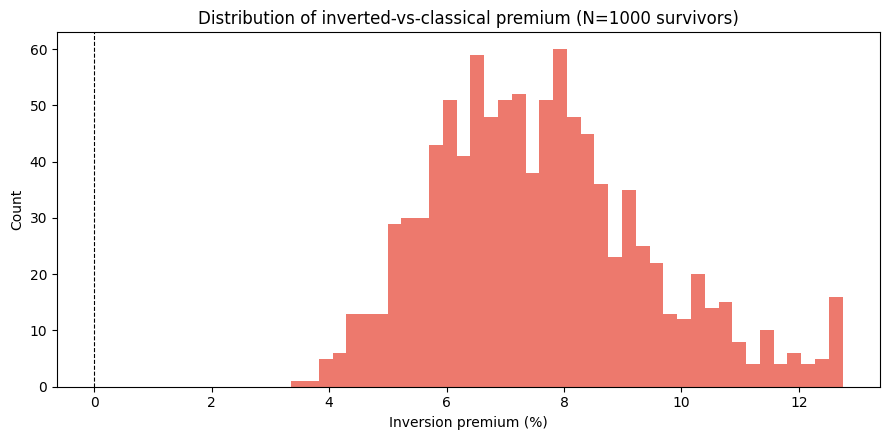

In [3]:
# Monte Carlo with 1000 runs
df_mc = run_monte_carlo(config, n_runs=1000, show_progress=False)
survived = df_mc[df_mc['survived']]
diff_pct = 100 * (survived['valuation_damodaran_inverted'] - survived['valuation_damodaran_classical']) / survived['valuation_damodaran_classical']

print(f'Survival: {100 * df_mc["survived"].mean():.1f}%')
print(f'Median inversion premium: {diff_pct.median():.2f}%')
print(f'5th-95th percentile inversion: {np.percentile(diff_pct, 5):.2f}% to {np.percentile(diff_pct, 95):.2f}%')
print(f'Runs with positive inversion: {100 * (diff_pct > 0).mean():.1f}%')

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(diff_pct, bins=40, color='#e74c3c', alpha=0.75)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Inversion premium (%)'); ax.set_ylabel('Count')
ax.set_title(f'Distribution of inverted-vs-classical premium (N={len(survived)} survivors)')
plt.tight_layout(); plt.show()

**Key insight.** In post-genAI conditions, the inversion of Damodaran's key-person discount is not exotic. It is the *default*. Every survival run produces a positive inversion premium, with median around +7% and tails extending to +12% and beyond. This is the empirical core of the paper's section 6.4.